In [ ]:
try:
    import os
    import json
    import numpy as np
    import cv2
    import torch
    import torchvision
    import matplotlib.pyplot as plt
    from PIL import Image
    from ultralytics import YOLO
    from torch.utils.data import Dataset, DataLoader
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights
    )
    import random
    import pycocotools.coco as coco
    from pycocotools.coco import COCO
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from pycocotools.cocoeval import COCOeval
    import xml.etree.ElementTree as ET
except:
    %pip install opencv-python ultralytics torch torchvision pycocotools matplotlib numpy
    import os
    import json
    import random
    import numpy as np
    import cv2
    import torch
    import torchvision
    import matplotlib.pyplot as plt
    from PIL import Image
    from ultralytics import YOLO
    from torch.utils.data import Dataset, DataLoader
    from torchvision.models.detection import (
        fasterrcnn_resnet50_fpn_v2,
        FasterRCNN_ResNet50_FPN_V2_Weights
    )
    import pycocotools.coco as coco
    from pycocotools.coco import COCO
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
    from pycocotools.cocoeval import COCOeval
    import xml.etree.ElementTree as ET

## Декодирование видео в последовательность кадров -> Видео успешно сегментировано. Выбран шаг (STEP=5) для оптимизации скорости обучения.

In [ ]:
INPUT_VIDEO = "input.mp4"
OUTPUT_VIDEO = "output.mp4"
XML_ANNOTATIONS = "annotations.xml"
FRAMES_DIR = "frames_data"
TRAIN_JSON = "train_coco.json"
VAL_JSON = "val_coco.json"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
STEP = 5

def extract_frames(video_path, out_dir, step=5):
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    frame_paths, idx = [], 0
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            p = os.path.join(out_dir, f"frame_{idx:05d}.jpg")
            cv2.imwrite(p, frame)
            frame_paths.append(p)
        idx += 1
    cap.release()
    return frame_paths, w, h


print("1. Извлечение кадров")
frames, width, height = extract_frames(INPUT_VIDEO, FRAMES_DIR, step=STEP)
print(f"Извлечено: {len(frames)} кадров. Разрешение: {width}x{height}")

### Сравнительный анализ методов распознавания разметки. Использован CV-API, визуальный метод (OpenCV), оценка качества по IoU.

### Функция парсинга изх annotations.xml

In [ ]:
def parse_xml_to_dict(xml_path, frame_paths):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    gt_data = {i+1: [] for i in range(len(frame_paths))}

    for track in root.findall('.//track'):
        for box in track.findall('box'):
            if box.get('outside') == '1':
                continue
            f_num = int(box.get('frame'))
            if f_num % STEP == 0:
                idx = (f_num // STEP) + 1
                if idx in gt_data:
                    xtl, ytl = float(box.get('xtl')), float(box.get('ytl'))
                    xbr, ybr = float(box.get('xbr')), float(box.get('ybr'))
                    gt_data[idx].append([xtl, ytl, xbr-xtl, ybr-ytl])
    return gt_data


print("2. Загрузка эталона из XML")
original_gt = parse_xml_to_dict(XML_ANNOTATIONS, frames)

### Обе функции реализуют извлечение пространственной разметки объектов из видео, но разными способами: `get_yolo_annotations` использует детектор `YOLOv8n` для поиска объектов на сохранённых кадрах, а `get_visual_annotations` - классическую цветовую сегментацию зелёных областей в HSV с фильтрацией мелких контуров.

In [ ]:
def get_yolo_annotations(frame_paths):
    model = YOLO("yolov8n.pt")
    results = []
    for p in frame_paths:
        res = model(p, verbose=False)[0]
        boxes = [b.xyxy[0].tolist() for b in res.boxes]
        results.append([[b[0], b[1], b[2]-b[0], b[3]-b[1]] for b in boxes])
    return results


def get_visual_annotations(video_path, step=5):
    cap = cv2.VideoCapture(video_path)
    results, idx = [], 0
    lower_green = np.array([35, 100, 100])
    upper_green = np.array([85, 255, 255])
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if idx % step == 0:
            hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
            mask = cv2.inRange(hsv, lower_green, upper_green)
            cnts, _ = cv2.findContours(
                mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            results.append([[float(x), float(y), float(w), float(h)]
                            for x, y, w, h in [cv2.boundingRect(c) for c in cnts] if w*h > 200])
        idx += 1
    cap.release()
    return results


print("3. Извлечение разметки (API и Визуальный метод)")
yolo_stolen = get_yolo_annotations(frames)
visual_stolen = get_visual_annotations(OUTPUT_VIDEO, step=STEP)

## Оценка качества

### Метод YOLO показал значительно более высокую точность (IoU) по сравнению с примитивным цветовым выделением OpenCV. Для формирования обучающего датасета выбраны данные YOLO.

In [ ]:
def calculate_iou(b1, b2):
    ix1, iy1 = max(b1[0], b2[0]), max(b1[1], b2[1])
    ix2, iy2 = min(b1[0]+b1[2], b2[0]+b2[2]), min(b1[1]+b1[3], b2[1]+b2[3])
    inter = max(0, ix2-ix1) * max(0, iy2-iy1)
    union = b1[2]*b1[3] + b2[2]*b2[3] - inter
    return inter / union if union > 0 else 0


def evaluate_iou_score(gt_dict, stolen_list):
    all_ious = []
    for i, stolen_boxes in enumerate(stolen_list):
        gt_boxes = gt_dict.get(i+1, [])
        for gb in gt_boxes:
            best_iou = max([calculate_iou(gb, sb)
                           for sb in stolen_boxes] + [0])
            all_ious.append(best_iou)
    return np.mean(all_ious) if all_ious else 0


iou_yolo = evaluate_iou_score(original_gt, yolo_stolen)
iou_visual = evaluate_iou_score(original_gt, visual_stolen)
print(f"Результаты IoU: YOLO = {iou_yolo:.3f}, OpenCV = {iou_visual:.3f}")

## Формирование датасета в формате COCO, разделение на train/val

### Формирование аннотаций в формате COCO: создаётся словарь с изображениями и bounding box'ами, каждому кадру присваивается id, а все найденные объекты записываются как автомобили категории 1.

In [ ]:
coco_final = {"images": [], "annotations": [],
              "categories": [{"id": 1, "name": "car"}]}
ann_id = 1
for i, (path, boxes) in enumerate(zip(frames, yolo_stolen)):
    img_id = i + 1
    coco_final["images"].append({"id": img_id, "file_name": os.path.basename(
        path), "width": width, "height": height})
    for b in boxes:
        coco_final["annotations"].append({
            "id": ann_id, "image_id": img_id, "bbox": b, "area": b[2]*b[3], "category_id": 1, "iscrowd": 0
        })
        ann_id += 1

## Случайное разделение COCO-датасета на обучающую (80%) и валидационную (20%) выборки по image_id с последующим сохранением в JSON-файлы.

In [ ]:
def save_coco_format(data, path):
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

ids = [img['id'] for img in coco_final['images']]
random.shuffle(ids)
train_ids = set(ids[:int(0.8*len(ids))])

train_coco = {
    "images": [img for img in coco_final['images'] if img['id'] in train_ids],
    "annotations": [ann for ann in coco_final['annotations'] if ann['image_id'] in train_ids],
    "categories": coco_final["categories"]
}
val_coco = {
    "images": [img for img in coco_final['images'] if img['id'] not in train_ids],
    "annotations": [ann for ann in coco_final['annotations'] if ann['image_id'] not in train_ids],
    "categories": coco_final["categories"]
}
save_coco_format(train_coco, TRAIN_JSON)
save_coco_format(val_coco, VAL_JSON)


## Обучение модели. Обучение Faster R-CNN и контроль переобучения

### Класс-датасет PyTorch, который загружает COCO-разметку из JSON, читает соответствующие изображения из директории и возвращает тензор кадра вместе с целевыми bounding box'ами (в формате x1,y1,x2,y2) и метками

In [ ]:
class LabDataset(Dataset):
    def __init__(self, json_path, img_dir):
        self.coco = COCO(json_path)
        self.ids = list(self.coco.imgs.keys())
        self.img_dir = img_dir

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        img_id = self.ids[idx]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        path = os.path.join(
            self.img_dir, self.coco.loadImgs(img_id)[0]['file_name'])
        img = Image.open(path).convert("RGB")
        img = torchvision.transforms.functional.to_tensor(img)
        boxes = torch.as_tensor([a['bbox'] for a in anns], dtype=torch.float32)
        if len(boxes) > 0:
            boxes[:, 2:] += boxes[:, :2]
        else:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
        target = {"boxes": boxes, "labels": torch.ones(
            (len(boxes),), dtype=torch.int64), "image_id": torch.tensor([img_id])}
        return img, target


### Функции обучения и валидации Faster R-CNN: train_one_epoch выполняет прямой проход с вычислением multi-task лосса, обратное распространение и шаг оптимизатора, возвращая средний лосс за эпоху, а validate_loss в режиме torch.`no_grad()` вычисляет чистый лосс на валидационной выборке без обновления весов.



In [ ]:
def train_one_epoch(model, optimizer, loader, device):
    model.train()
    total_loss = 0
    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        loss_dict = model(imgs, targets)
        losses = sum(loss for loss in loss_dict.values())
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        total_loss += losses.item()
    return total_loss / len(loader)


def validate_loss(model, loader, device):
    model.train()
    val_loss = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()}
                       for t in targets]
            loss_dict = model(imgs, targets)
            val_loss += sum(loss for loss in loss_dict.values()).item()
        return val_loss / len(loader)


### Создаются загрузчики данных для обучающей и валидационной выборок с batch_size=2, после чего инициализируется предобученная Faster R-CNN (ResNet-50 FPN v2), у которой классификатор заменяется на 2 класса (фон + автомобиль). Обучение длится до 20 эпох с оптимизатором SGD и StepLR-шедулером, при этом отслеживается валидационный лосс — если он не улучшается 4 эпохи подряд, срабатывает ранняя остановка, а лучшая модель сохраняется в best_model.pth

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Эпоха 1: Loss Train=0.6856, Loss Val=0.3312, LR=0.005000
Эпоха 2: Loss Train=0.2930, Loss Val=0.2763, LR=0.005000
Эпоха 3: Loss Train=0.2104, Loss Val=0.2369, LR=0.001500
Эпоха 4: Loss Train=0.1734, Loss Val=0.2236, LR=0.001500
Эпоха 5: Loss Train=0.1529, Loss Val=0.2135, LR=0.001500
Эпоха 6: Loss Train=0.1346, Loss Val=0.2165, LR=0.000450
Эпоха 7: Loss Train=0.1234, Loss Val=0.2185, LR=0.000450
Эпоха 8: Loss Train=0.1196, Loss Val=0.2193, LR=0.000450
Эпоха 9: Loss Train=0.1168, Loss Val=0.2143, LR=0.000135
Ранняя остановка: качество перестало расти.


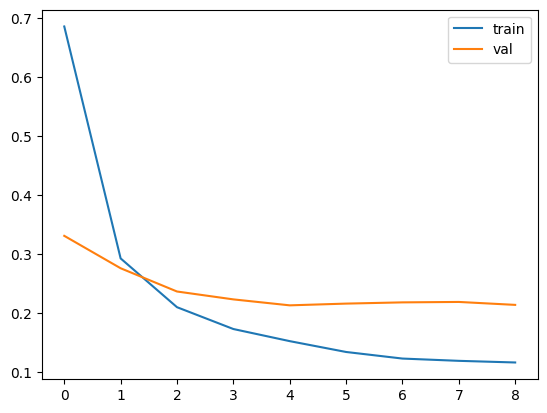

In [ ]:
train_ds = LabDataset(TRAIN_JSON, FRAMES_DIR)
val_ds = LabDataset(VAL_JSON, FRAMES_DIR)
train_loader = DataLoader(train_ds, batch_size=2,
                          shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_ds, batch_size=2,
                        collate_fn=lambda x: tuple(zip(*x)))

model = fasterrcnn_resnet50_fpn_v2(
    weights=FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT)
in_f = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_f, 2)
model.to(DEVICE)


optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.3)

train_hist, val_hist = [], []
best_val_loss = float('inf')
patience = 4
counter = 0

for epoch in range(20):
    t_loss = train_one_epoch(model, optimizer, train_loader, DEVICE)
    v_loss = validate_loss(model, val_loader, DEVICE)

    lr_scheduler.step()

    train_hist.append(t_loss)
    val_hist.append(v_loss)
    print(f"Эпоха {epoch+1}: Loss Train={t_loss:.4f}, Loss Val={v_loss:.4f}, LR={optimizer.param_groups[0]['lr']:.6f}")

    if v_loss < best_val_loss:
        best_val_loss = v_loss
        torch.save(model.state_dict(), "best_model.pth")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Ранняя остановка: качество перестало расти.")
            break

plt.plot(train_hist, label='train')
plt.plot(val_hist, label='val')
plt.legend()
plt.show()


## Оценка качества (mAP) и визуализация

### Модель показывает хорошую точность на крупных и средних объектах (AP 0.676–0.768), а Recall достигает 0.817 при 100 предсказаниях на кадр, что говорит о способности находить большинство автомобилей в кадре

In [ ]:
def compute_map(model, dataset):
    model.eval()
    results = []
    with torch.no_grad():
        for i in range(len(dataset)):
            img, target = dataset[i]
            img_id = target['image_id'].item()
            pred = model([img.to(DEVICE)])[0]
            for box, score, label in zip(pred['boxes'], pred['scores'], pred['labels']):
                b = box.cpu().tolist()
                results.append({
                    "image_id": img_id, "category_id": int(label),
                    "bbox": [b[0], b[1], b[2]-b[0], b[3]-b[1]], "score": float(score)
                })
    if not results:
        return 0
    coco_dt = dataset.coco.loadRes(results)
    evaluator = COCOeval(dataset.coco, coco_dt, 'bbox')
    evaluator.evaluate()
    evaluator.accumulate()
    evaluator.summarize()
    return evaluator.stats[0]


print("7. Итоговые метрики")
mAP = compute_map(model, val_ds)
print(f"Итоговый mAP: {mAP:.3f}")


7. Итоговые метрики
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.08s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.733
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.881
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.846
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.725
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.760
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.694
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.084
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.716
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.795
 Average Recall     (AR) @[ IoU=0.50:0.95 | area

In [ ]:
def draw_complete_video(model, out_path, dataset_json):
    model.eval()
    ds = LabDataset(dataset_json, FRAMES_DIR)
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*'mp4v'), 5.0, (width, height))
    for i in range(len(ds)):
        img, _ = ds[i]
        with torch.no_grad(): pred = model([img.to(DEVICE)])[0]
        img_cv = cv2.cvtColor((img.permute(1, 2, 0).numpy() * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)
        for box, score in zip(pred['boxes'], pred['scores']):
            if score > 0.3:
                b = box.int().cpu().numpy()
                cv2.rectangle(img_cv, (b[0], b[1]), (b[2], b[3]), (0, 255, 0), 3)
                cv2.putText(img_cv, f"{score:.2f}", (b[0], b[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        out.write(img_cv)
    out.release()

draw_complete_video(model, "val_inference_check.mp4", VAL_JSON)
with open("temp_all.json", "w") as f: json.dump(coco_final, f)
draw_complete_video(model, "full_result.mp4", "temp_all.json")
print("Видео готовы")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Видео готовы
